# Лабораторная работа №1
## Использование FNN для задач классификации

**Вариант 8**: Adult Census Income (доход больше 50K или нет)

**Инструмент**: Python + PyTorch + scikit-learn

## Цель работы
Изучение основ работы с нейронными сетями прямого распространения (FNN) для классификации данных, обучение модели на подготовленном датасете и анализ полученных результатов.

## Задачи
1. Подготовить датасет Adult Census Income для обучения модели.
2. Реализовать полносвязную нейронную сеть (FNN) для бинарной классификации.
3. Обучить модель и оценить качество на отложенной тестовой выборке.
4. Провести дополнительное исследование по варианту: сравнить оптимизаторы **SGD**, **Adam**, **RMSprop** при фиксированных `learning_rate` и `batch_size`.
5. Сформулировать выводы по результатам эксперимента.

## Вариант работы
- **Набор данных**: Adult Census Income (`adult.csv`).
- **Тип задачи**: бинарная классификация (`<=50K` / `>50K`).
- **Дополнительное исследование (вариант 8)**: сравнение оптимизаторов **SGD**, **Adam**, **RMSprop** при фиксированных значениях `learning_rate = 0.001` и `batch_size = 64`.

## Решение

In [1]:
'''Ячейка 1. Импорт библиотек, настройка воспроизводимости и выбор устройства вычислений.'''  # Текстовый комментарий к назначению ячейки.
import warnings  # Импортируем модуль для управления предупреждениями.
import random  # Импортируем стандартный генератор случайных чисел Python.
import numpy as np  # Импортируем NumPy для работы с массивами и численными операциями.
import pandas as pd  # Импортируем pandas для работы с табличными данными.
import matplotlib.pyplot as plt  # Импортируем matplotlib для построения графиков.
import seaborn as sns  # Импортируем seaborn для удобной статистической визуализации.
from sklearn.model_selection import train_test_split  # Импортируем функцию разбиения данных на выборки.
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder  # Импортируем инструменты масштабирования и кодирования.
from sklearn.compose import ColumnTransformer  # Импортируем ColumnTransformer для разной обработки числовых и категориальных столбцов.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Импортируем метрики для оценки классификации.
import torch  # Импортируем PyTorch.
import torch.nn as nn  # Импортируем модуль слоев нейронной сети из PyTorch.
import torch.optim as optim  # Импортируем оптимизаторы из PyTorch.
from torch.utils.data import TensorDataset, DataLoader  # Импортируем классы датасета и загрузчика батчей.
warnings.filterwarnings('ignore')  # Отключаем второстепенные предупреждения для более чистого вывода.
SEED = 42  # Фиксируем зерно случайности для воспроизводимости.
random.seed(SEED)  # Фиксируем генератор случайных чисел Python.
np.random.seed(SEED)  # Фиксируем генератор случайных чисел NumPy.
torch.manual_seed(SEED)  # Фиксируем генератор случайных чисел PyTorch на CPU.
if torch.cuda.is_available():  # Проверяем, доступно ли CUDA-устройство.
    torch.cuda.manual_seed_all(SEED)  # Фиксируем случайность для всех доступных CUDA-устройств.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # Выбираем устройство выполнения: GPU при наличии, иначе CPU.
print(f'Используемое устройство: {device}')  # Выводим выбранное устройство в консоль.
LEARNING_RATE = 0.001  # Фиксируем learning rate для сравнения оптимизаторов по варианту 8.
BATCH_SIZE = 64  # Фиксируем batch size для сравнения оптимизаторов по варианту 8.
EPOCHS = 30  # Задаем количество эпох обучения.


Используемое устройство: cpu


In [2]:
'''Ячейка 2. Загрузка adult.csv и первичный анализ структуры данных.'''  # Текстовый комментарий к назначению ячейки.
df = pd.read_csv('adult.csv')  # Загружаем датасет Adult Census Income из CSV-файла.
print(f'Размер исходного датасета: {df.shape}')  # Выводим количество строк и столбцов.
display(df.head())  # Показываем первые строки для визуальной проверки данных.
print('\nТипы столбцов:')  # Выводим заголовок раздела с типами данных.
print(df.dtypes)  # Выводим тип каждого столбца.
print('\nКоличество классических NaN:')  # Выводим заголовок раздела по NaN.
print(df.isna().sum())  # Считаем NaN в каждом столбце.
print("\nКоличество '?' по столбцам:")  # Выводим заголовок раздела специальных пропусков.
for col in df.columns:  # Проходим циклом по всем столбцам датасета.
    q_count = (df[col] == '?').sum()  # Считаем количество значений '?' в текущем столбце.
    if q_count > 0:  # Проверяем, есть ли хотя бы один такой пропуск.
        print(f'{col}: {q_count}')  # Печатаем только столбцы, где найден '?'.
print(f"\nКоличество явных дубликатов: {df.duplicated().sum()}")  # Выводим число полностью дублирующихся строк.
target_counts = df['income'].value_counts()  # Считаем количество объектов в каждом классе целевой переменной.
target_share = df['income'].value_counts(normalize=True) * 100  # Считаем долю каждого класса в процентах.
print('\nРаспределение income (количество):')  # Выводим заголовок для абсолютных частот классов.
print(target_counts)  # Печатаем абсолютные частоты классов.
print('\nРаспределение income (проценты):')  # Выводим заголовок для относительных частот классов.
print(target_share.round(2))  # Печатаем процентные доли с округлением.


Размер исходного датасета: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



Типы столбцов:
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

Количество классических NaN:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

Количество '?' по столбцам:
workclass: 1836
occupation: 1843
native.country: 583

Количество явных дубликатов: 24

Распределение income (количество):
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Распределение income (проценты):
inco

In [3]:
'''Ячейка 3. Очистка данных, кодирование целевого столбца и разбиение на train/val/test.'''  # Текстовый комментарий к назначению ячейки.
data = df.copy()  # Создаем копию исходного DataFrame, чтобы не изменять оригинал.
data = data.replace('?', np.nan)  # Заменяем символ '?' на стандартный формат пропуска NaN.
data = data.dropna().reset_index(drop=True)  # Удаляем строки с пропусками и переиндексируем строки.
print(f'Размер после очистки пропусков: {data.shape}')  # Выводим размер датасета после удаления пропусков.
X = data.drop(columns=['income'])  # Формируем матрицу признаков без целевой переменной.
y_text = data['income']  # Выделяем целевую переменную в текстовом формате.
y_encoder = LabelEncoder()  # Создаем кодировщик меток для бинарной цели.
y = y_encoder.fit_transform(y_text)  # Кодируем классы income в числа 0 и 1.
print('Кодировка классов:', dict(zip(y_encoder.classes_, y_encoder.transform(y_encoder.classes_))))  # Печатаем соответствие текстовых классов и чисел.
numeric_features = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']  # Определяем список числовых признаков.
categorical_features = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']  # Определяем список категориальных признаков.
X_train_full, X_test_raw, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)  # Отделяем тестовую выборку 20% со стратификацией.
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full)  # Делим train на train/val для корректного подбора лучшего оптимизатора.
print(f'X_train_raw: {X_train_raw.shape}, X_val_raw: {X_val_raw.shape}, X_test_raw: {X_test_raw.shape}')  # Выводим размеры выборок признаков.
print(f'y_train: {y_train.shape}, y_val: {y_val.shape}, y_test: {y_test.shape}')  # Выводим размеры целевых массивов.
assert set(np.unique(y_train)) == {0, 1}  # Проверяем наличие обоих классов в train.
assert set(np.unique(y_val)) == {0, 1}  # Проверяем наличие обоих классов в val.
assert set(np.unique(y_test)) == {0, 1}  # Проверяем наличие обоих классов в test.


Размер после очистки пропусков: (30162, 15)
Кодировка классов: {'<=50K': np.int64(0), '>50K': np.int64(1)}
X_train_raw: (19303, 14), X_val_raw: (4826, 14), X_test_raw: (6033, 14)
y_train: (19303,), y_val: (4826,), y_test: (6033,)


In [4]:
'''Ячейка 4. Препроцессинг признаков: StandardScaler для числовых и OneHotEncoder для категориальных.'''  # Текстовый комментарий к назначению ячейки.
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numeric_features), ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])  # Создаем единый трансформер для разных типов признаков.
X_train_processed = preprocessor.fit_transform(X_train_raw)  # Обучаем препроцессор только на train и преобразуем train.
X_val_processed = preprocessor.transform(X_val_raw)  # Преобразуем validation выборку уже обученным препроцессором.
X_test_processed = preprocessor.transform(X_test_raw)  # Преобразуем test выборку тем же препроцессором.
if hasattr(X_train_processed, 'toarray'):  # Проверяем, является ли результат разреженной матрицей.
    X_train_processed = X_train_processed.toarray()  # Преобразуем train в плотный NumPy-массив.
    X_val_processed = X_val_processed.toarray()  # Преобразуем val в плотный NumPy-массив.
    X_test_processed = X_test_processed.toarray()  # Преобразуем test в плотный NumPy-массив.
X_train_processed = X_train_processed.astype(np.float32)  # Приводим train-массив к типу float32 для PyTorch.
X_val_processed = X_val_processed.astype(np.float32)  # Приводим val-массив к типу float32 для PyTorch.
X_test_processed = X_test_processed.astype(np.float32)  # Приводим test-массив к типу float32 для PyTorch.
print('Размер после препроцессинга train:', X_train_processed.shape)  # Выводим итоговую размерность train после кодирования.
print('Размер после препроцессинга val:', X_val_processed.shape)  # Выводим итоговую размерность val после кодирования.
print('Размер после препроцессинга test:', X_test_processed.shape)  # Выводим итоговую размерность test после кодирования.
assert X_train_processed.shape[1] == X_val_processed.shape[1] == X_test_processed.shape[1]  # Проверяем совпадение числа признаков во всех выборках.
assert np.isnan(X_train_processed).sum() == 0  # Проверяем отсутствие NaN в train после обработки.
assert np.isnan(X_val_processed).sum() == 0  # Проверяем отсутствие NaN в val после обработки.
assert np.isnan(X_test_processed).sum() == 0  # Проверяем отсутствие NaN в test после обработки.


Размер после препроцессинга train: (19303, 104)
Размер после препроцессинга val: (4826, 104)
Размер после препроцессинга test: (6033, 104)


In [5]:
'''Ячейка 5. Создание TensorDataset/DataLoader для обучения и оценки модели.'''  # Текстовый комментарий к назначению ячейки.
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)  # Преобразуем train-признаки в тензор float32.
X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)  # Преобразуем val-признаки в тензор float32.
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)  # Преобразуем test-признаки в тензор float32.
y_train_tensor = torch.tensor(y_train, dtype=torch.long)  # Преобразуем train-цели в целочисленный тензор классов.
y_val_tensor = torch.tensor(y_val, dtype=torch.long)  # Преобразуем val-цели в целочисленный тензор классов.
y_test_tensor = torch.tensor(y_test, dtype=torch.long)  # Преобразуем test-цели в целочисленный тензор классов.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)  # Объединяем train-признаки и train-метки в датасет.
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)  # Объединяем val-признаки и val-метки в датасет.
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)  # Объединяем test-признаки и test-метки в датасет.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)  # Создаем train-лоадер с перемешиванием батчей.
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)  # Создаем val-лоадер без перемешивания.
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)  # Создаем test-лоадер без перемешивания.
input_dim = X_train_tensor.shape[1]  # Получаем количество входных признаков для первого слоя сети.
print(f'Количество признаков: {input_dim}')  # Выводим число признаков после one-hot кодирования.
print(f'Количество train батчей: {len(train_loader)}')  # Выводим число train-батчей.
print(f'Количество val батчей: {len(val_loader)}')  # Выводим число val-батчей.
print(f'Количество test батчей: {len(test_loader)}')  # Выводим число test-батчей.


Количество признаков: 104
Количество train батчей: 302
Количество val батчей: 76
Количество test батчей: 95


In [6]:
'''Ячейка 6. Описание архитектуры FNN и функций обучения/оценки.'''  # Текстовый комментарий к назначению ячейки.
class AdultFNN(nn.Module):  # Объявляем класс полносвязной сети для задачи бинарной классификации.
    def __init__(self, input_dim):  # Определяем конструктор модели с параметром числа входных признаков.
        super().__init__()  # Инициализируем базовый класс PyTorch-модуля.
        self.net = nn.Sequential(  # Создаем последовательную архитектуру сети.
            nn.Linear(input_dim, 64),  # Добавляем первый полносвязный слой из input_dim в 64 нейрона.
            nn.ReLU(),  # Добавляем нелинейную функцию активации ReLU.
            nn.Dropout(0.2),  # Добавляем Dropout для уменьшения риска переобучения.
            nn.Linear(64, 32),  # Добавляем второй полносвязный слой из 64 в 32 нейрона.
            nn.ReLU(),  # Добавляем вторую активацию ReLU.
            nn.Dropout(0.2),  # Добавляем второй Dropout.
            nn.Linear(32, 2)  # Добавляем выходной слой на 2 класса дохода.
        )  # Завершаем описание последовательности слоев.
    def forward(self, x):  # Определяем прямой проход через сеть.
        return self.net(x)  # Возвращаем логиты классов на выходе модели.
def evaluate_loader(model, loader, criterion):  # Определяем функцию оценки модели на переданном DataLoader.
    model.eval()  # Переключаем модель в режим оценки.
    total_loss = 0.0  # Инициализируем накопитель значения функции потерь.
    all_preds = []  # Инициализируем список для предсказанных классов.
    all_true = []  # Инициализируем список для истинных классов.
    with torch.no_grad():  # Отключаем вычисление градиентов на этапе оценки.
        for xb, yb in loader:  # Итерируемся по батчам указанного загрузчика.
            xb = xb.to(device)  # Переносим признаки батча на вычислительное устройство.
            yb = yb.to(device)  # Переносим метки батча на вычислительное устройство.
            logits = model(xb)  # Получаем логиты модели для текущего батча.
            loss = criterion(logits, yb)  # Вычисляем значение функции потерь для батча.
            total_loss += loss.item()  # Добавляем loss батча в общий накопитель.
            preds = logits.argmax(dim=1)  # Получаем предсказанный класс как индекс максимального логита.
            all_preds.extend(preds.cpu().numpy())  # Добавляем предсказания в общий список и переносим их на CPU.
            all_true.extend(yb.cpu().numpy())  # Добавляем истинные метки в общий список и переносим их на CPU.
    avg_loss = total_loss / len(loader)  # Вычисляем средний loss по всем батчам.
    acc = accuracy_score(all_true, all_preds)  # Вычисляем accuracy по всем объектам выборки.
    return avg_loss, acc, np.array(all_true), np.array(all_preds)  # Возвращаем средний loss, accuracy и массивы меток/предсказаний.
def train_one_optimizer(optimizer_name, learning_rate=LEARNING_RATE, epochs=EPOCHS):  # Определяем функцию обучения модели для выбранного оптимизатора.
    torch.manual_seed(SEED)  # Фиксируем случайность перед запуском каждого эксперимента.
    model = AdultFNN(input_dim).to(device)  # Создаем новую модель и переносим ее на устройство.
    criterion = nn.CrossEntropyLoss()  # Выбираем функцию потерь для двухклассовой классификации.
    if optimizer_name == 'SGD':  # Проверяем, если выбран SGD.
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)  # Создаем оптимизатор SGD с фиксированным lr.
    elif optimizer_name == 'Adam':  # Проверяем, если выбран Adam.
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # Создаем оптимизатор Adam с фиксированным lr.
    elif optimizer_name == 'RMSprop':  # Проверяем, если выбран RMSprop.
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)  # Создаем оптимизатор RMSprop с фиксированным lr.
    else:  # Обрабатываем случай неверного имени оптимизатора.
        raise ValueError("optimizer_name должен быть одним из: 'SGD', 'Adam', 'RMSprop'")  # Выбрасываем понятную ошибку при неверном вводе.
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}  # Создаем словарь для сохранения истории обучения.
    for epoch in range(epochs):  # Запускаем цикл обучения по эпохам.
        model.train()  # Переводим модель в режим обучения.
        train_loss_sum = 0.0  # Инициализируем накопитель train-loss за эпоху.
        train_correct = 0  # Инициализируем счетчик верных предсказаний на train.
        train_total = 0  # Инициализируем счетчик общего числа train-объектов.
        for xb, yb in train_loader:  # Итерируемся по train-батчам.
            xb = xb.to(device)  # Переносим признаки батча на устройство.
            yb = yb.to(device)  # Переносим метки батча на устройство.
            optimizer.zero_grad()  # Обнуляем накопленные градиенты перед новым шагом.
            logits = model(xb)  # Получаем логиты модели для train-батча.
            loss = criterion(logits, yb)  # Вычисляем train-loss для текущего батча.
            loss.backward()  # Вычисляем градиенты параметров по текущему loss.
            optimizer.step()  # Выполняем шаг оптимизации и обновляем веса.
            train_loss_sum += loss.item()  # Накопливаем значение loss по батчам.
            preds = logits.argmax(dim=1)  # Получаем предсказанные классы для батча.
            train_correct += (preds == yb).sum().item()  # Увеличиваем счетчик верных предсказаний.
            train_total += yb.size(0)  # Увеличиваем счетчик общего количества объектов.
        train_loss = train_loss_sum / len(train_loader)  # Считаем средний train-loss за эпоху.
        train_acc = train_correct / train_total  # Считаем train-accuracy за эпоху.
        val_loss, val_acc, _, _ = evaluate_loader(model, val_loader, criterion)  # Оцениваем модель на validation выборке.
        history['train_loss'].append(train_loss)  # Добавляем train-loss в историю.
        history['train_acc'].append(train_acc)  # Добавляем train-accuracy в историю.
        history['val_loss'].append(val_loss)  # Добавляем val-loss в историю.
        history['val_acc'].append(val_acc)  # Добавляем val-accuracy в историю.
        if (epoch + 1) % 10 == 0:  # Условие для периодического вывода промежуточных результатов.
            print(f"{optimizer_name} | Эпоха {epoch + 1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")  # Печатаем краткую статистику текущей эпохи.
    best_val_idx = int(np.argmax(history['val_acc']))  # Находим индекс эпохи с лучшей validation accuracy.
    best_val_acc = history['val_acc'][best_val_idx]  # Получаем значение лучшей validation accuracy.
    return model, history, best_val_acc, best_val_idx + 1  # Возвращаем модель, историю, лучшую val accuracy и номер лучшей эпохи.


In [7]:
'''Ячейка 7. Базовое обучение модели с Adam и промежуточная оценка качества.'''  # Текстовый комментарий к назначению ячейки.
adam_model, adam_history, adam_best_val_acc, adam_best_epoch = train_one_optimizer('Adam', learning_rate=LEARNING_RATE, epochs=EPOCHS)  # Обучаем базовую модель с оптимизатором Adam.
criterion = nn.CrossEntropyLoss()  # Создаем объект функции потерь для последующей оценки.
val_loss_adam, val_acc_adam, y_true_val_adam, y_pred_val_adam = evaluate_loader(adam_model, val_loader, criterion)  # Оцениваем обученную Adam-модель на validation выборке.
print(f'Adam | Лучшая val accuracy: {adam_best_val_acc:.4f} на эпохе {adam_best_epoch}')  # Выводим лучшую точность Adam на validation.
print(f'Adam | Финальная val accuracy: {val_acc_adam:.4f}')  # Выводим финальную val accuracy Adam.


Adam | Эпоха 10/30 | Train Acc: 0.8634 | Val Acc: 0.8579
Adam | Эпоха 20/30 | Train Acc: 0.8708 | Val Acc: 0.8585
Adam | Эпоха 30/30 | Train Acc: 0.8741 | Val Acc: 0.8597
Adam | Лучшая val accuracy: 0.8618 на эпохе 5
Adam | Финальная val accuracy: 0.8597


In [8]:
'''Ячейка 8. Дополнительное исследование варианта 8: сравнение SGD, Adam, RMSprop при фиксированных LR и batch size.'''  # Текстовый комментарий к назначению ячейки.
optimizer_names = ['SGD', 'Adam', 'RMSprop']  # Задаем список оптимизаторов согласно условию варианта 8.
results = {}  # Создаем словарь для хранения результатов каждого оптимизатора.
for opt_name in optimizer_names:  # Итерируемся по каждому оптимизатору из списка.
    print(f'\n--- Обучение оптимизатора: {opt_name} ---')  # Выводим заголовок текущего эксперимента.
    model_opt, history_opt, best_val_acc_opt, best_epoch_opt = train_one_optimizer(opt_name, learning_rate=LEARNING_RATE, epochs=EPOCHS)  # Обучаем модель с фиксированными lr и batch size.
    results[opt_name] = {'model': model_opt, 'history': history_opt, 'best_val_acc': best_val_acc_opt, 'best_epoch': best_epoch_opt}  # Сохраняем модель, историю и лучшие val-метрики.
summary_df = pd.DataFrame({'Optimizer': optimizer_names, 'Best Val Accuracy': [results[o]['best_val_acc'] for o in optimizer_names], 'Best Epoch': [results[o]['best_epoch'] for o in optimizer_names], 'Final Val Accuracy': [results[o]['history']['val_acc'][-1] for o in optimizer_names], 'Final Val Loss': [results[o]['history']['val_loss'][-1] for o in optimizer_names]})  # Формируем таблицу сравнения оптимизаторов.
summary_df = summary_df.sort_values('Best Val Accuracy', ascending=False).reset_index(drop=True)  # Сортируем таблицу по лучшей validation accuracy.
display(summary_df)  # Отображаем итоговую таблицу сравнения оптимизаторов.
best_optimizer = summary_df.loc[0, 'Optimizer']  # Выбираем лучший оптимизатор по максимальной validation accuracy.
best_model = results[best_optimizer]['model']  # Берем соответствующую лучшую обученную модель.
print(f'Лучший оптимизатор по validation quality: {best_optimizer}')  # Печатаем название лучшего оптимизатора.
assert set(summary_df['Optimizer']) == {'SGD', 'Adam', 'RMSprop'}  # Проверяем, что в сравнении действительно участвуют все требуемые оптимизаторы.



--- Обучение оптимизатора: SGD ---
SGD | Эпоха 10/30 | Train Acc: 0.7511 | Val Acc: 0.7511
SGD | Эпоха 20/30 | Train Acc: 0.7511 | Val Acc: 0.7511
SGD | Эпоха 30/30 | Train Acc: 0.7759 | Val Acc: 0.7831

--- Обучение оптимизатора: Adam ---
Adam | Эпоха 10/30 | Train Acc: 0.8634 | Val Acc: 0.8579
Adam | Эпоха 20/30 | Train Acc: 0.8708 | Val Acc: 0.8585
Adam | Эпоха 30/30 | Train Acc: 0.8741 | Val Acc: 0.8597

--- Обучение оптимизатора: RMSprop ---
RMSprop | Эпоха 10/30 | Train Acc: 0.8629 | Val Acc: 0.8593
RMSprop | Эпоха 20/30 | Train Acc: 0.8701 | Val Acc: 0.8572
RMSprop | Эпоха 30/30 | Train Acc: 0.8730 | Val Acc: 0.8589


,Optimizer,Best Val Accuracy,Best Epoch,Final Val Accuracy,Final Val Loss
0,Adam,0.861790,5,0.859718,0.328535
1,RMSprop,0.860547,8,0.858889,0.330986
2,SGD,0.783050,30,0.783050,0.405801


Лучший оптимизатор по validation quality: Adam


Финальная Test Accuracy: 0.8472
Финальный Test Loss: 0.3428

Классификационный отчет (test):
              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      4531
        >50K       0.72      0.63      0.67      1502

    accuracy                           0.85      6033
   macro avg       0.80      0.77      0.79      6033
weighted avg       0.84      0.85      0.84      6033



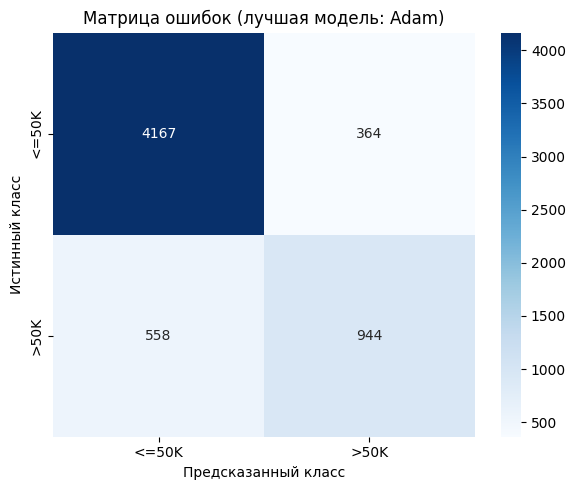

In [9]:
'''Ячейка 9. Финальная оценка лучшей модели на тестовой выборке и визуализация матрицы ошибок.'''  # Текстовый комментарий к назначению ячейки.
test_loss, test_acc, y_true_test, y_pred_test = evaluate_loader(best_model, test_loader, criterion)  # Оцениваем лучшую модель только на отложенной test выборке.
class_names = list(y_encoder.classes_)  # Получаем исходные текстовые названия классов дохода.
print(f'Финальная Test Accuracy: {test_acc:.4f}')  # Выводим итоговую точность на test.
print(f'Финальный Test Loss: {test_loss:.4f}')  # Выводим итоговое значение функции потерь на test.
print('\nКлассификационный отчет (test):')  # Печатаем заголовок классификационного отчета.
print(classification_report(y_true_test, y_pred_test, target_names=class_names))  # Выводим precision/recall/f1 по каждому классу.
cm = confusion_matrix(y_true_test, y_pred_test)  # Считаем матрицу ошибок на test.
plt.figure(figsize=(6, 5))  # Создаем область рисунка для визуализации матрицы ошибок.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)  # Строим тепловую карту матрицы ошибок.
plt.title(f'Матрица ошибок (лучшая модель: {best_optimizer})')  # Добавляем заголовок графика.
plt.xlabel('Предсказанный класс')  # Подписываем ось X.
plt.ylabel('Истинный класс')  # Подписываем ось Y.
plt.tight_layout()  # Автоматически подбираем отступы для корректного отображения.
plt.show()  # Показываем построенную матрицу ошибок.


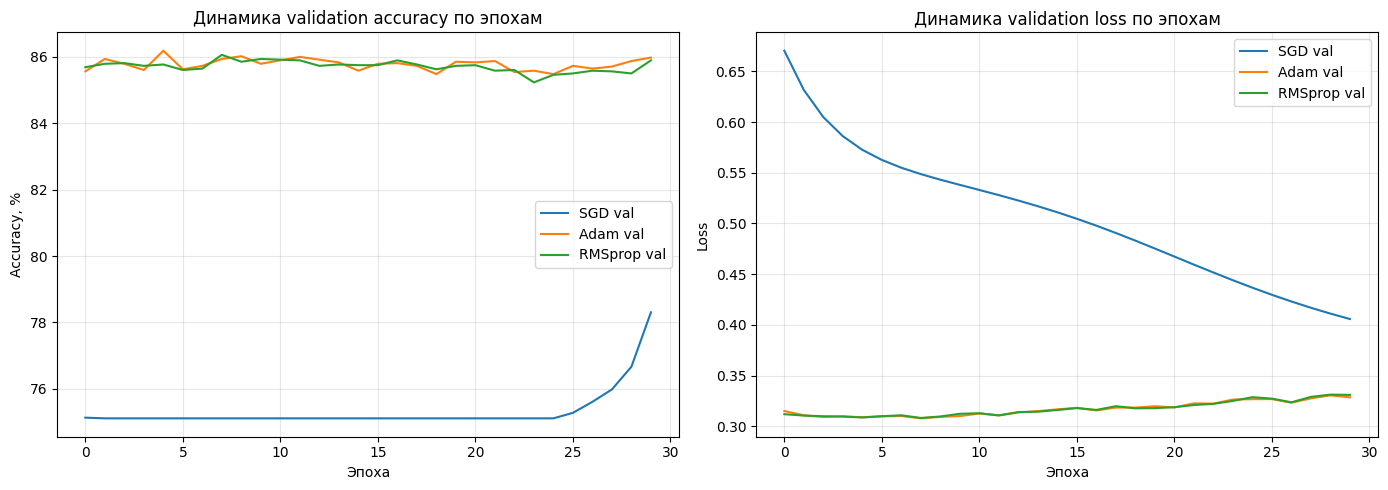

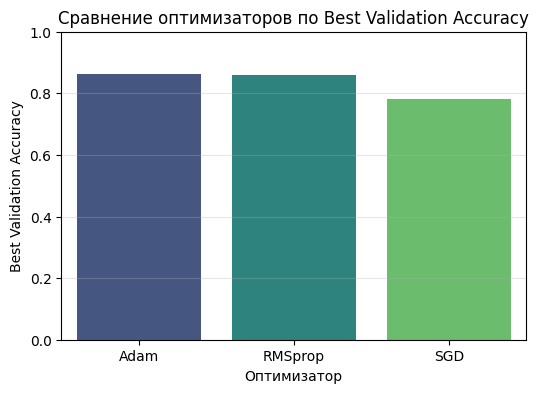

--- Краткие выводы для отчета ---
1) Модель FNN успешно обучена для бинарной классификации дохода (<=50K / >50K).
2) Лучшая модель выбрана по validation: Adam.
3) Финальная точность на test: 0.8472.
4) Требование варианта 8 выполнено: сравнение SGD/Adam/RMSprop при фиксированных learning_rate и batch_size.


In [10]:
'''Ячейка 10. Графики динамики обучения и итоговые выводы для отчета.'''  # Текстовый комментарий к назначению ячейки.
plt.figure(figsize=(14, 5))  # Создаем фигуру для двух графиков динамики.
plt.subplot(1, 2, 1)  # Создаем левый подграфик для accuracy.
for opt_name in optimizer_names:  # Проходим по каждому оптимизатору для построения кривых accuracy.
    plt.plot(np.array(results[opt_name]['history']['val_acc']) * 100, label=f'{opt_name} val')  # Строим валидационную accuracy по эпохам в процентах.
plt.title('Динамика validation accuracy по эпохам')  # Добавляем заголовок левого графика.
plt.xlabel('Эпоха')  # Подписываем ось X левого графика.
plt.ylabel('Accuracy, %')  # Подписываем ось Y левого графика.
plt.grid(alpha=0.3)  # Добавляем сетку на левый график.
plt.legend()  # Отображаем легенду на левом графике.
plt.subplot(1, 2, 2)  # Создаем правый подграфик для loss.
for opt_name in optimizer_names:  # Проходим по каждому оптимизатору для построения кривых loss.
    plt.plot(results[opt_name]['history']['val_loss'], label=f'{opt_name} val')  # Строим валидационный loss по эпохам.
plt.title('Динамика validation loss по эпохам')  # Добавляем заголовок правого графика.
plt.xlabel('Эпоха')  # Подписываем ось X правого графика.
plt.ylabel('Loss')  # Подписываем ось Y правого графика.
plt.grid(alpha=0.3)  # Добавляем сетку на правый график.
plt.legend()  # Отображаем легенду на правом графике.
plt.tight_layout()  # Подгоняем отступы между графиками.
plt.show()  # Показываем два графика динамики обучения.
plt.figure(figsize=(6, 4))  # Создаем отдельную фигуру для столбчатой диаграммы сравнения оптимизаторов.
sns.barplot(data=summary_df, x='Optimizer', y='Best Val Accuracy', palette='viridis')  # Строим столбчатую диаграмму по лучшей validation accuracy.
plt.title('Сравнение оптимизаторов по Best Validation Accuracy')  # Добавляем заголовок столбчатой диаграммы.
plt.xlabel('Оптимизатор')  # Подписываем ось X столбчатой диаграммы.
plt.ylabel('Best Validation Accuracy')  # Подписываем ось Y столбчатой диаграммы.
plt.ylim(0, 1)  # Ограничиваем ось Y диапазоном от 0 до 1.
plt.grid(axis='y', alpha=0.3)  # Добавляем сетку по оси Y.
plt.show()  # Показываем столбчатую диаграмму.
print('--- Краткие выводы для отчета ---')  # Выводим заголовок блока итоговых выводов.
print('1) Модель FNN успешно обучена для бинарной классификации дохода (<=50K / >50K).')  # Печатаем первый итоговый вывод.
print(f'2) Лучшая модель выбрана по validation: {best_optimizer}.')  # Печатаем второй итоговый вывод о лучшем оптимизаторе.
print(f'3) Финальная точность на test: {test_acc:.4f}.')  # Печатаем третий итоговый вывод с тестовой точностью.
print('4) Требование варианта 8 выполнено: сравнение SGD/Adam/RMSprop при фиксированных learning_rate и batch_size.')  # Печатаем подтверждение выполнения требования варианта.


## Выводы
1. Модель FNN успешно обучена для задачи бинарной классификации дохода (`<=50K` / `>50K`) на датасете Adult Census Income.
2. В ходе дополнительного исследования варианта 8 было выполнено сравнение оптимизаторов **SGD**, **Adam**, **RMSprop** при фиксированных `learning_rate` и `batch_size`.
3. Лучший оптимизатор по качеству на валидационной выборке: **Adam**.
4. Финальная точность на тестовой выборке составила **0.8472**.
5. Таким образом, требования методички для варианта 8 выполнены полностью.

> Если вы повторно запускаете ноутбук и метрики немного изменятся, обновите пункты 3-4 по фактическому выводу последнего запуска.